# Quetions to help company make business decisions accordingly

- Q1) What is the most frequent genre of movies released on Netflix?
- Q2) Which genre has the highest average popularity?
- Q3) what movies got highest popularity? what's its genre? 
- Q4) How has movie production changed over the years?
- Q5) Is there a relationship between movie popularity and vote count?

In [2]:
import pandas as pd
import numpy as np

In [3]:
df= pd.read_csv('netflixdata.csv', engine= 'python' )
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [5]:
df.duplicated().sum()

0

In [6]:
df['Vote_Count']= pd.to_numeric(df['Vote_Count'], errors= 'coerce')
df['Vote_Average']= pd.to_numeric(df['Vote_Average'], errors='coerce')

In [7]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9826.000000,9826.000000
mean,40.320570,1392.943721,6.439467
std,108.874308,2611.303856,1.129797
min,7.100000,0.000000,0.000000
25%,16.127500,146.000000,5.900000
50%,21.191000,444.000000,6.500000
75%,35.174500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [8]:
df['Release_Date']= pd.to_datetime(df['Release_Date'], errors= 'coerce')
#df['Release_date']= df['Release_date'].dt.year
#df['Release_Date'].head()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[ns]
 1   Title              9828 non-null   object        
 2   Overview           9828 non-null   object        
 3   Popularity         9827 non-null   float64       
 4   Vote_Count         9826 non-null   float64       
 5   Vote_Average       9826 non-null   float64       
 6   Original_Language  9827 non-null   object        
 7   Genre              9826 non-null   object        
 8   Poster_Url         9826 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 691.8+ KB


In [10]:
df['Release_Date']= df['Release_Date'].dt.year

In [11]:
df['Release_Date'].head()

0    2021.0
1    2022.0
2    2022.0
3    2021.0
4    2021.0
Name: Release_Date, dtype: float64

In [12]:
cols= ['Overview','Original_Language','Poster_Url']

In [13]:
df.drop(cols, inplace= True, axis= 1)
df.head(3)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,8.3,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151.0,8.1,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122.0,6.3,Thriller


### Dividing the vote_average column into 4 category

- We will divide the Vote_Average column into 4 labels i.e popular, average, below_average and not_popular. With help of function cat_votes given below.

In [15]:
#df['Popularity'].describe()['25%']
df['Vote_Average'].head()

0    8.3
1    8.1
2    6.3
3    7.7
4    7.0
Name: Vote_Average, dtype: float64

In [16]:
def cat_votes(df,cols, labels ):
    demo= [df[cols].describe()['min'],
          df[cols].describe()['25%'],
           df[cols].describe()['50%'],
          df[cols].describe()['75%'],
          df[cols].describe()['max']]
    df[cols] = pd.cut(df[cols],demo, duplicates='drop', labels=labels)
    return df[cols]

In [17]:
labels= ['NOT_POPULAR','BELOW_AVERAGE','AVERAGE','POPULAR']
cat_votes(df, 'Vote_Average',labels)
df['Vote_Average'].unique()

['POPULAR', 'BELOW_AVERAGE', 'AVERAGE', 'NOT_POPULAR', NaN]
Categories (4, object): ['NOT_POPULAR' < 'BELOW_AVERAGE' < 'AVERAGE' < 'POPULAR']

In [18]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,POPULAR,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151.0,POPULAR,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122.0,BELOW_AVERAGE,Thriller
3,2021.0,Encanto,2402.201,5076.0,POPULAR,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793.0,AVERAGE,"Action, Adventure, Thriller, War"


In [19]:
df.dropna(inplace=True)

df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [20]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,POPULAR,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151.0,POPULAR,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122.0,BELOW_AVERAGE,Thriller
3,2021.0,Encanto,2402.201,5076.0,POPULAR,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793.0,AVERAGE,"Action, Adventure, Thriller, War"


In [21]:
df['Genre']= df['Genre'].str.split(', ')
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,POPULAR,"[Action, Adventure, Science Fiction]"
1,2022.0,The Batman,3827.658,1151.0,POPULAR,"[Crime, Mystery, Thriller]"
2,2022.0,No Exit,2618.087,122.0,BELOW_AVERAGE,[Thriller]
3,2021.0,Encanto,2402.201,5076.0,POPULAR,"[Animation, Comedy, Family, Fantasy]"
4,2021.0,The King's Man,1895.511,1793.0,AVERAGE,"[Action, Adventure, Thriller, War]"


In [22]:
df= df.explode('Genre').reset_index(drop= True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940.0,POPULAR,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940.0,POPULAR,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940.0,POPULAR,Science Fiction
3,2022.0,The Batman,3827.658,1151.0,POPULAR,Crime
4,2022.0,The Batman,3827.658,1151.0,POPULAR,Mystery


In [23]:
df['Genre']= df['Genre'].astype('category')
df['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25551 non-null  float64 
 1   Title         25551 non-null  object  
 2   Popularity    25551 non-null  float64 
 3   Vote_Count    25551 non-null  float64 
 4   Vote_Average  25551 non-null  category
 5   Genre         25551 non-null  category
dtypes: category(2), float64(3), object(1)
memory usage: 849.4+ KB


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns 

## Q1) What is the most frequent genre of movies released on Netflix?

*  We are creating a Bar chart 

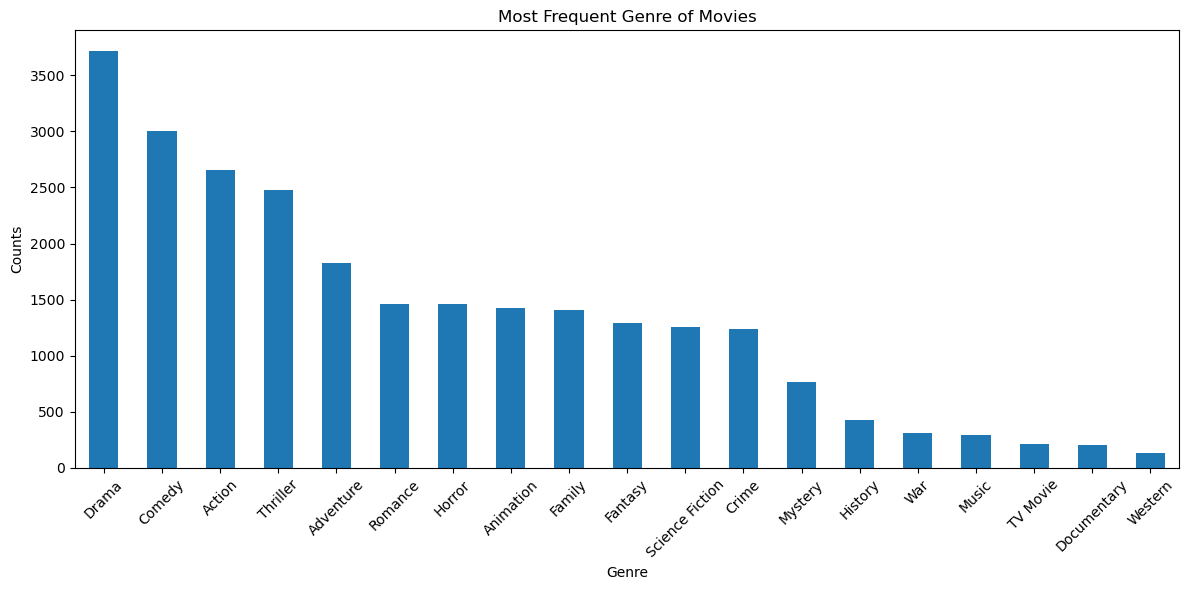

In [28]:
genre_counts= df['Genre'].value_counts()


plt.figure(figsize=(12,6))
genre_counts.plot(kind= 'bar')
plt.title('Most Frequent Genre of Movies')
plt.xlabel('Genre')
plt.ylabel('Counts')
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()

## Q2) Which genre has the highest average popularity?

C:\Users\Admin\AppData\Local\Temp\ipykernel_9856\873758007.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_votes = df.groupby('Genre')['Popularity'].sum().sort_values(ascending=False)


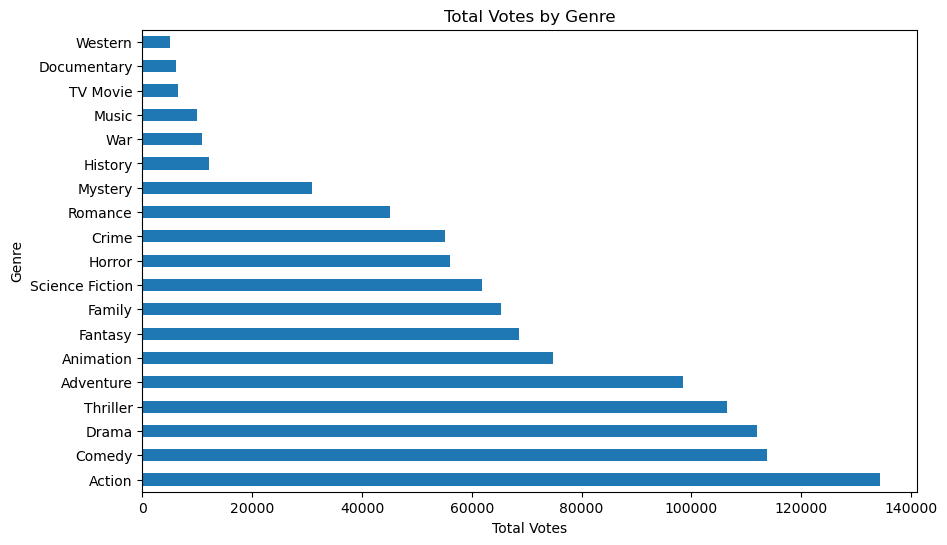

Genre with Highest Votes:
Genre
Action    134426.795
Name: Popularity, dtype: float64


In [30]:
genre_votes = df.groupby('Genre')['Popularity'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
genre_votes.plot(kind='barh')

plt.title('Total Votes by Genre')
plt.xlabel('Total Votes')
plt.ylabel('Genre')

plt.show()

print("Genre with Highest Votes:")
print(genre_votes.head(1))

## Q3) What are the top 5 most popular movies, and which genres do they belong to?

#### Since I exploded the Genre column, a single movie appeared multiple times. When finding the Top 10 most popular movies, this caused duplicate movie entries. To solve this, I grouped the dataset by movie title, merged all genres into a single field using join(), retained the maximum popularity value, and then sorted the unique movies by popularity. This ensured that each movie appeared only once in the Top 10 list.

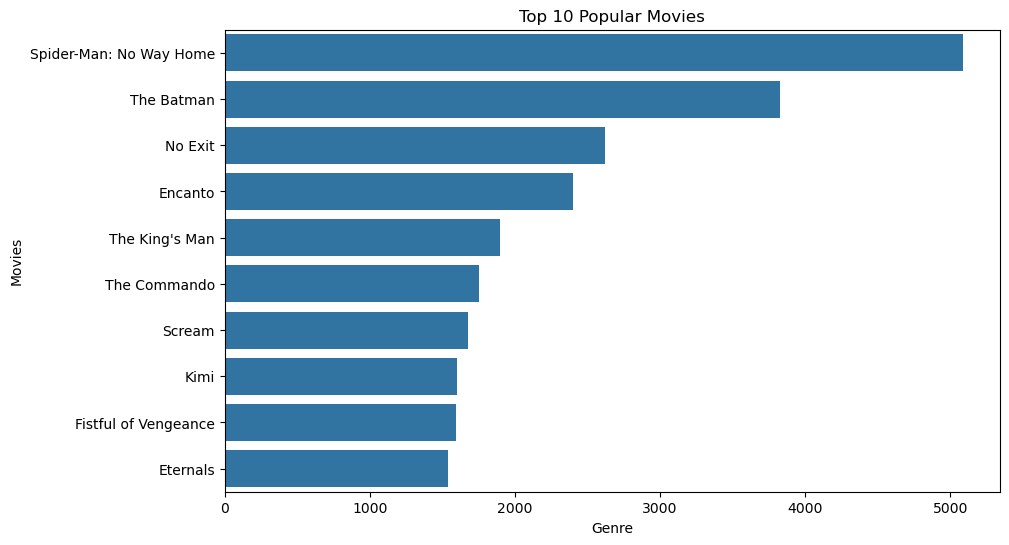

                        Title                               Genre  Popularity
6534  Spider-Man: No Way Home  Action, Adventure, Science Fiction    5083.954
7017               The Batman            Crime, Mystery, Thriller    3827.658
5048                  No Exit                            Thriller    2618.087
2436                  Encanto  Animation, Comedy, Family, Fantasy    2402.201
7710           The King's Man    Action, Adventure, Thriller, War    1895.511
7183             The Commando             Action, Crime, Thriller    1750.484
6138                   Scream    Crime, Horror, Mystery, Thriller    1675.161
3999                     Kimi                            Thriller    1601.782
2706     Fistful of Vengeance              Action, Crime, Fantasy    1594.013
2490                 Eternals                     Science Fiction    1537.406


In [69]:
movies_df = (
    df.groupby('Title')
      .agg({
          'Genre': lambda x: ', '.join(sorted(set(x))),
          'Popularity':'max'
      })
      .reset_index()
)

top10= movies_df.sort_values(by= 'Popularity', ascending= False ).head(10)

plt.figure(figsize=(10,6))

sns.barplot(data= top10, x= 'Popularity', y= 'Title')
plt.title("Top 10 Popular Movies")
plt.xlabel('Genre')
plt.ylabel('Movies')
plt.show()
print(top10)

## Q4) How has movie production changed over the years?

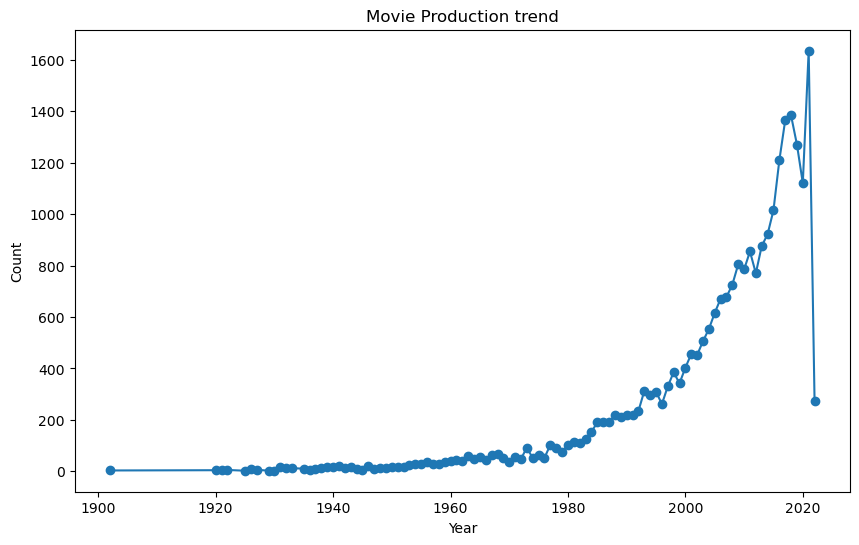

Year with maximum number of movies :  2021.0    Number of movies produced:  1636
Year with minimum number of movies :  1925.0    Number of movies produced:  2


In [98]:
times_movie= df['Release_Date'].value_counts().sort_index()
plt.figure(figsize= (10,6))
plt.plot(
    times_movie.index,
    times_movie.values,
    marker='o'
)

plt.title('Movie Production trend')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

print('Year with maximum number of movies : ', times_movie.idxmax(),"  ","Number of movies produced: " ,times_movie.max())
print('Year with minimum number of movies : ', times_movie.idxmin(),"  ","Number of movies produced: "  ,times_movie.min() )

## Q5) Is there a relationship between movie popularity and vote count?

### The scatter plot was used to analyze the relationship between movie popularity and vote count. Each point represents a movie. Most movies are concentrated at lower popularity values, while a few movies act as outliers with extremely high popularity scores. The plot indicates that there is only a weak positive relationship between popularity and vote count, meaning that movies with a higher number of votes are not necessarily the most popular. This suggests that popularity is influenced by additional factors beyond audience voting.

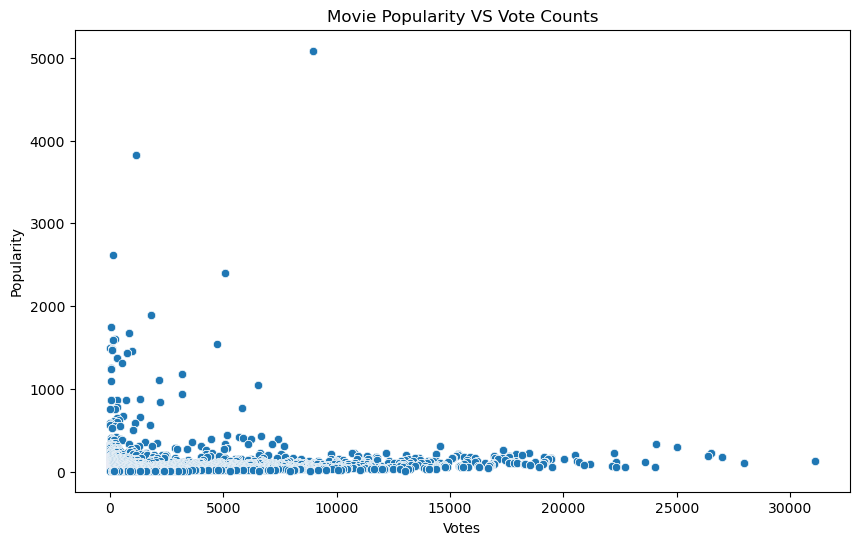

max vote:  31077.0


In [111]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x= 'Vote_Count' , y='Popularity')
plt.title('Movie Popularity VS Vote Counts')
plt.xlabel('Votes')
plt.ylabel('Popularity')
plt.show()

print('max vote: ', df['Vote_Count'].max())